In [129]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

/kaggle/input/snotel-alldata/snotel_data_alldata_morecolumns.csv
/kaggle/input/snotel-first8/snotel_data_first8_morecolumns.csv
/kaggle/input/snotel-first30/snotel_data_first30_morecolumns.csv


In [137]:
file_path = "/kaggle/input/snotel-alldata/snotel_data_alldata_morecolumns.csv"
data = pd.read_csv(file_path)

data['Date'] = pd.to_datetime(data['Date'])
#data['dayofyear'] = data['Date'].dt.dayofyear
data['month'] = data['Date'].dt.month

drop_columns = {'Date','site_name','state','site',
               'Snow Rain Ratio','SWE Max (in)','Snow Density SoD (pct)'}

data=data.drop(columns=drop_columns)

drop_every = 10
data = data.iloc[::drop_every]
data.drop_duplicates(inplace=True) # drop the duplicate rows
data.dropna(inplace=True) # drop any rows that have NA values

for col in ['SWE (in)', 'Depth SoD (in)', 'Precip Inc (in)']:
    data[col] = np.log1p(data[col])

In [138]:
categorical_features = [' lat','lon']
continuous_features = ['month','Precip Accum SoD (in)','Air Temp Avg (F)','Air Temp Max (F)','Air Temp Obs SoD (F)','Air Temp Min (F)',
                'Precip Month-to-Date SoD (in)','Precip Inc (in)','Depth SoD (in)','Precip Inc Snow-adj (in)']

for feature in categorical_features:
    le = LabelEncoder()
    data[feature] = le.fit_transform(data[feature])

X = data.drop('SWE (in)', axis=1)
y = data['SWE (in)']

scaler = StandardScaler()
X[continuous_features] = scaler.fit_transform(X[continuous_features])

t_s = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_s, random_state=42)

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [139]:
class SnotelMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SnotelMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.model(x)

#    def forward(self, x):
#       x = self.dropout(self.relu(self.bn1(self.fc1(x))))
#        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
#        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
#        x = self.dropout(self.relu(self.bn4(self.fc4(x))))
#        x = self.fc5(x)
#        return x

In [161]:
input_dim = X_train.shape[1]
output_dim = 1

learning_rate=0.001
b_s = 64

#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SnotelMLP(input_dim, output_dim)#.to(device)

loss_function = nn.MSELoss()#SmoothL1Loss()  # Better for regression with noise
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

# Dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=b_s, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=b_s, shuffle=False)



In [171]:
# Training loop
num_epochs = 100
best_loss = float('inf')
patience = 10
epochs_since_improvement = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs).squeeze(1)
            loss = loss_function(outputs, labels)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
   # print(f"Test Loss after Epoch {epoch+1}: {avg_test_loss:.4f}")
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss:.4f}, Test Loss: {avg_test_loss:.4f}")


    scheduler.step(avg_test_loss)

    # Early stopping
    if avg_test_loss < best_loss:
        best_loss = avg_test_loss
        epochs_since_improvement = 0
    else:
        epochs_since_improvement += 1

    if epochs_since_improvement >= patience:
        print("Early stopping triggered.")
        break

Epoch [1/100], Train Loss: 0.0595, Test Loss: 0.0639
Epoch [2/100], Train Loss: 0.0584, Test Loss: 0.1196
Epoch [3/100], Train Loss: 0.0573, Test Loss: 0.0356
Epoch [4/100], Train Loss: 0.0567, Test Loss: 0.0926
Epoch [5/100], Train Loss: 0.0558, Test Loss: 0.0565
Epoch [6/100], Train Loss: 0.0552, Test Loss: 0.0342
Epoch [7/100], Train Loss: 0.0552, Test Loss: 0.1378
Epoch [8/100], Train Loss: 0.0553, Test Loss: 0.0341
Epoch [9/100], Train Loss: 0.0544, Test Loss: 0.0543
Epoch [10/100], Train Loss: 0.0541, Test Loss: 0.0567
Epoch [11/100], Train Loss: 0.0534, Test Loss: 0.0436
Epoch [12/100], Train Loss: 0.0507, Test Loss: 0.0373
Epoch [13/100], Train Loss: 0.0506, Test Loss: 0.0444
Epoch [14/100], Train Loss: 0.0495, Test Loss: 0.0418
Epoch [15/100], Train Loss: 0.0485, Test Loss: 0.0359
Epoch [16/100], Train Loss: 0.0480, Test Loss: 0.0469
Epoch [17/100], Train Loss: 0.0477, Test Loss: 0.0390
Epoch [18/100], Train Loss: 0.0470, Test Loss: 0.0384
Early stopping triggered.


In [176]:
model.eval()
predictions = []
true_values = []

#with torch.no_grad():
#    predictions = model(X_test_tensor).squeeze().numpy()  # Get predictions as NumPy array
#    true_values = y_test_tensor.numpy()

with torch.no_grad():
    for inputs, labels in test_loader:
        #inputs = inputs.to(device)
        outputs = model(inputs).squeeze(1)
        predictions.extend(outputs.cpu().numpy())
        true_values.extend(labels.cpu().numpy())

predictions = np.array(predictions)
true_values = np.array(true_values)

r2 = r2_score(true_values, predictions)
print(f"R² Score on Test Data: {r2:.4f}")

mae = mean_absolute_error(true_values, predictions)
print(f"MAE: {mae:.4f}")

R² Score on Test Data: -27.0616
MAE: 4.4364


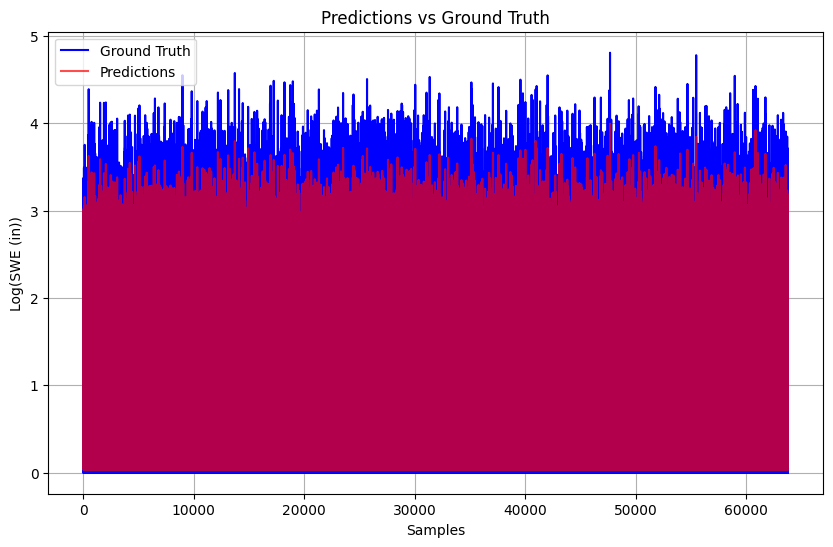

In [178]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(true_values, label='Ground Truth', color='blue')
plt.plot(predictions, label='Predictions', color='red', alpha=0.7)
plt.xlabel('Samples')
plt.ylabel('Log(SWE (in))')
plt.title('Predictions vs Ground Truth')
plt.legend()
plt.grid(True)
plt.show()

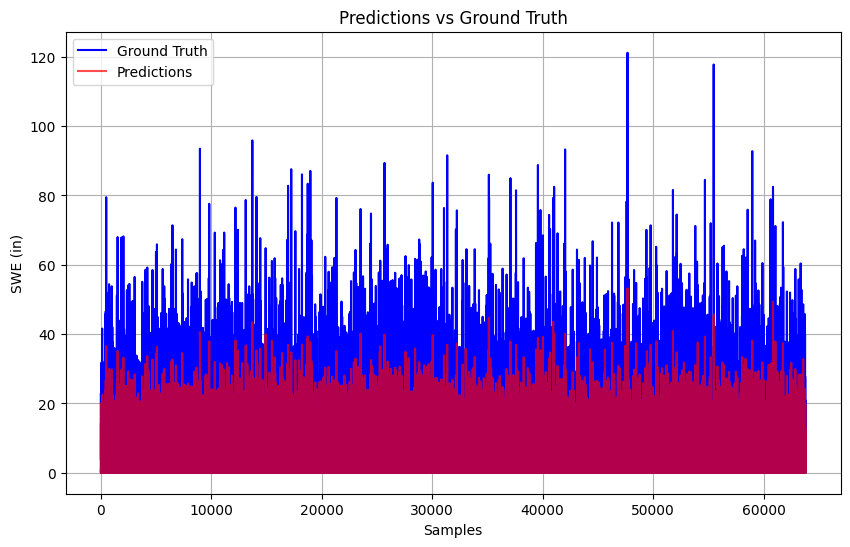

In [174]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(np.expm1(true_values), label='Ground Truth', color='blue')
plt.plot(np.expm1(predictions), label='Predictions', color='red', alpha=0.7)
plt.xlabel('Samples')
plt.ylabel('SWE (in)')
plt.title('Predictions vs Ground Truth')
plt.legend()
plt.grid(True)
plt.show()

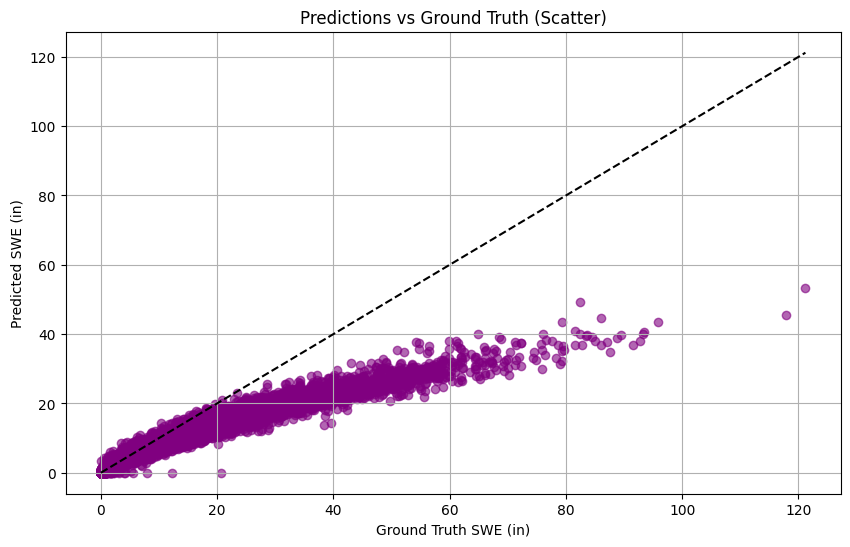

In [175]:
plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(true_values), np.expm1(predictions), alpha=0.6, color='purple')
plt.xlabel('Ground Truth SWE (in)')
plt.ylabel('Predicted SWE (in)')
plt.title('Predictions vs Ground Truth (Scatter)')
plt.grid(True)
plt.plot([0, max(np.expm1(true_values).max(), np.expm1(predictions).max())], 
         [0, max(np.expm1(true_values).max(), np.expm1(predictions).max())], 
         color='black', linestyle='--')  # 1:1 reference line
plt.show()